# Classification Modeling on the Adult Income Dataset

**Student:** Flor Trejo  
**Course:** DS 301 - Week 8 - Day 4  
**Case Study:** Adult Income Classification

## Problem statement

The objective is to build classification models that predict whether an adult's annual income is **greater than $50,000** or **less than or equal to $50,000**, using demographic, education, employment, relationship, and financial attributes.

- **Target feature:** `income`
- **Independent variables:** all remaining predictors, including age, workclass, final sampling weight (`fnlwgt`), education level/number, marital status, occupation, relationship, race, sex, capital gain, capital loss, hours worked per week, and native country.
- **Type of problem:** **binary classification**, because the target has exactly two categories: `<=50K` and `>50K`.

The notebook compares:

1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Decision Tree
4. Support Vector Machine (Linear SVM)

The models are evaluated before and after handling class imbalance with SMOTE. The main comparison metric is ROC-AUC, supported by accuracy, precision, recall, F1-score, and the classification report.

## 1. Import libraries and configure the notebook

In [1]:
from pathlib import Path
import warnings
import gc
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier, plot_tree

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

## 2. Load and inspect the dataset

In [2]:
# The CSV should be stored in the same folder as this notebook.
DATA_PATH = Path("adult_income.csv")
if not DATA_PATH.exists():
    # Fallback used in the current execution environment.
    DATA_PATH = Path("/mnt/data/adult_income.csv")

# Treat common Adult-dataset missing markers as NaN.
data_raw = pd.read_csv(DATA_PATH, na_values=["?", " ?", "?"])

print(f"Dataset loaded from: {DATA_PATH}")
print(f"Original shape: {data_raw.shape[0]:,} rows and {data_raw.shape[1]} columns")

Dataset loaded from: adult_income.csv
Original shape: 48,842 rows and 15 columns


### First 20 rows

In [3]:
display(data_raw.head(20))

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


### Data types, dimensions, and duplicate records

In [4]:
print("Shape:", data_raw.shape)
print("\nData types:")
display(data_raw.dtypes.to_frame("dtype"))

print(f"Exact duplicate rows: {data_raw.duplicated().sum():,}")

Shape: (48842, 15)

Data types:


,dtype
age,int64
workclass,object
fnlwgt,int64
education,object
education_num,int64
marital_status,object
occupation,object
relationship,object
race,object
sex,object


Exact duplicate rows: 52


### Initial cleaning decisions

- Leading and trailing spaces are removed from text columns so categories such as `Private` and ` Private` are not treated as different values.
- Exact duplicate rows are removed because they contain no additional information and may allow the same observation to appear in both the training and test sets.
- Missing predictor values are **not dropped**. They will be imputed as an `Unknown` category inside the preprocessing pipeline, which preserves all records and prevents data leakage.
- The target is label encoded as `0 = <=50K` and `1 = >50K`.
- `education` and `education_num` describe the same ordered concept. `education_num` is retained and the text version is removed from modeling to avoid duplicate information and unnecessary multicollinearity.

In [5]:
data = data_raw.copy()

# Standardize text values while preserving true missing values.
text_columns = data.select_dtypes(include="object").columns
for column in text_columns:
    data[column] = data[column].str.strip()

rows_before = len(data)
data = data.drop_duplicates().reset_index(drop=True)
rows_after = len(data)

# Label-encode the binary target.
data["income"] = data["income"].map({"<=50K": 0, ">50K": 1})

if data["income"].isna().any():
    raise ValueError("Unexpected target labels were found. Inspect the income column.")

data["income"] = data["income"].astype(int)

print(f"Rows before duplicate removal: {rows_before:,}")
print(f"Rows after duplicate removal:  {rows_after:,}")
print(f"Duplicate rows removed:        {rows_before - rows_after:,}")
print("Target mapping: 0 = <=50K, 1 = >50K")

Rows before duplicate removal: 48,842
Rows after duplicate removal:  48,790
Duplicate rows removed:        52
Target mapping: 0 = <=50K, 1 = >50K


## 3. Missing-value analysis

In [6]:
missing_table = pd.DataFrame({
    "missing_count": data.isna().sum(),
    "missing_percent": data.isna().mean() * 100,
}).sort_values("missing_count", ascending=False)

missing_table = missing_table[missing_table["missing_count"] > 0]
display(missing_table)

,missing_count,missing_percent
occupation,2805,5.7491
workclass,2795,5.7286
native_country,856,1.7545


### Missing-value interpretation

Missing values occur only in categorical predictors. Dropping these rows would discard several thousand observations. Instead, the preprocessing pipeline uses a constant category named `Unknown`. This approach:

- keeps every non-duplicate record;
- avoids pretending that the most frequent category is known to be correct;
- allows the model to learn whether missingness itself contains predictive information; and
- fits the imputer only on the training data, preventing leakage from the test set.

## 4. Target distribution and class imbalance

,count,percent
income,,
<=50K,37109,76.0600
>50K,11681,23.9400


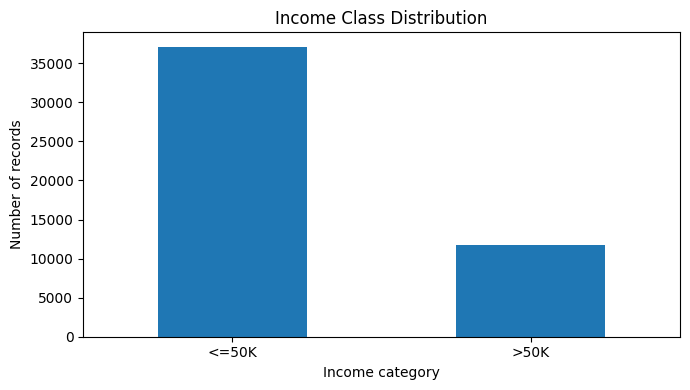

In [7]:
class_distribution = data["income"].value_counts().sort_index().rename(index={0: "<=50K", 1: ">50K"})
class_percent = (class_distribution / class_distribution.sum() * 100).round(2)
class_summary = pd.DataFrame({"count": class_distribution, "percent": class_percent})
display(class_summary)

ax = class_distribution.plot(kind="bar", figsize=(7, 4), rot=0)
ax.set_title("Income Class Distribution")
ax.set_xlabel("Income category")
ax.set_ylabel("Number of records")
plt.tight_layout()
plt.show()
plt.close()

The `<=50K` class is substantially larger than the `>50K` class. A model can therefore obtain a high overall accuracy while still missing many higher-income records. For this reason, minority-class recall, F1-score, and ROC-AUC are considered in addition to accuracy.

## 5. Numerical distributions and outlier analysis

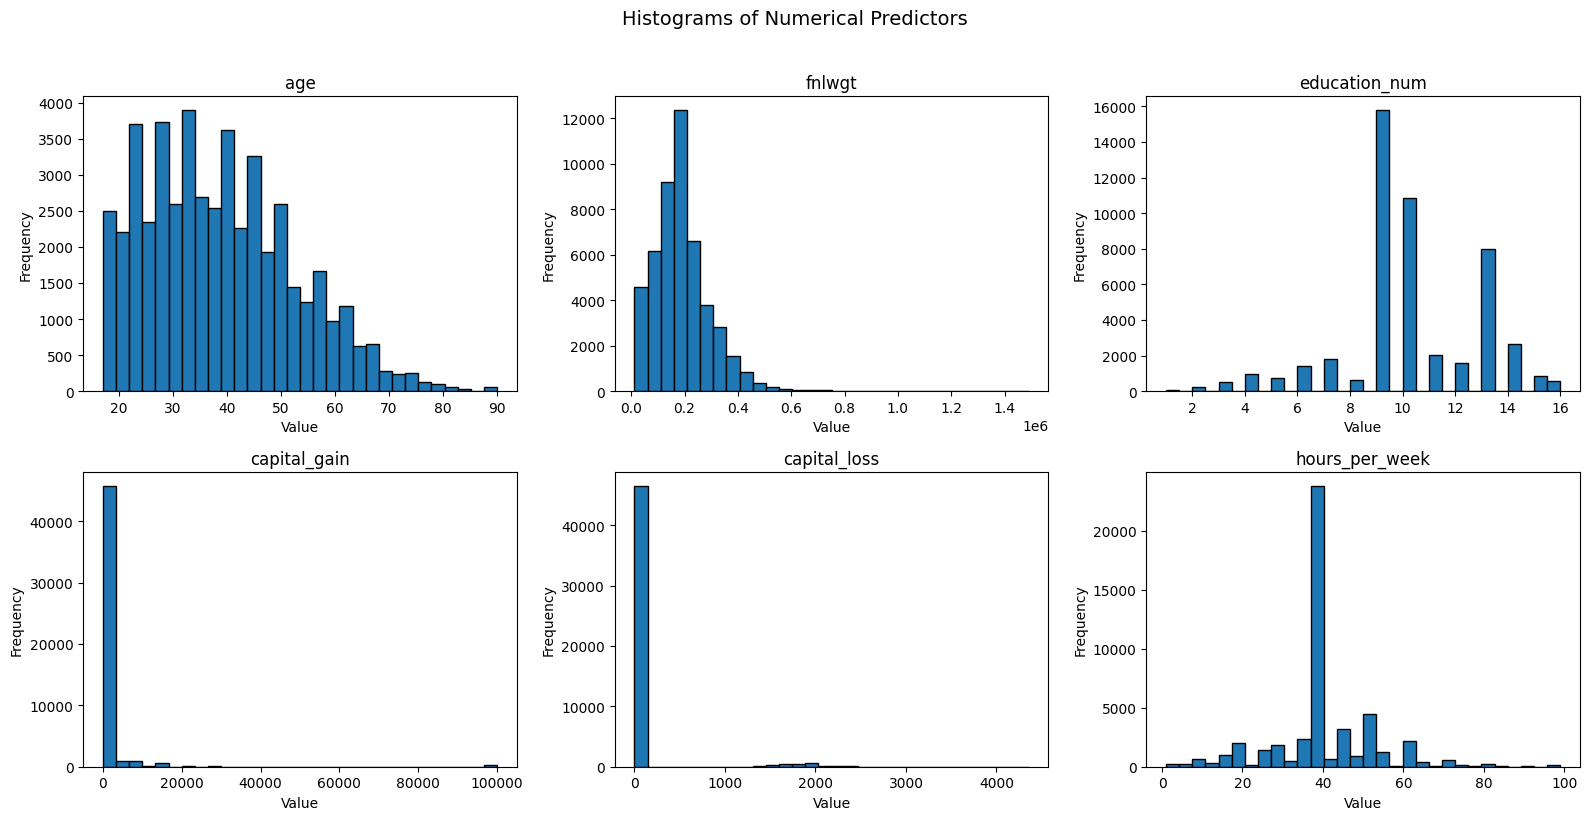

In [8]:
numerical_columns = data.select_dtypes(include=np.number).columns.drop("income").tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for axis, column in zip(axes, numerical_columns):
    axis.hist(data[column].dropna(), bins=30, edgecolor="black")
    axis.set_title(column)
    axis.set_xlabel("Value")
    axis.set_ylabel("Frequency")

plt.suptitle("Histograms of Numerical Predictors", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()
plt.close()

### Histogram observations

- `age` is right-skewed, with more observations among younger and middle-aged adults.
- `fnlwgt` is strongly right-skewed because a small number of records have very large population weights.
- `education_num` is discrete and concentrated around high-school and some-college levels.
- `capital_gain` and `capital_loss` are zero-inflated: most adults report zero, while a small minority report positive values.
- `hours_per_week` is strongly concentrated around 40 hours, with smaller groups working very low or very high hours.

These distributions indicate that StandardScaler would be sensitive to extreme values. RobustScaler is more appropriate because it centers by the median and scales by the interquartile range.

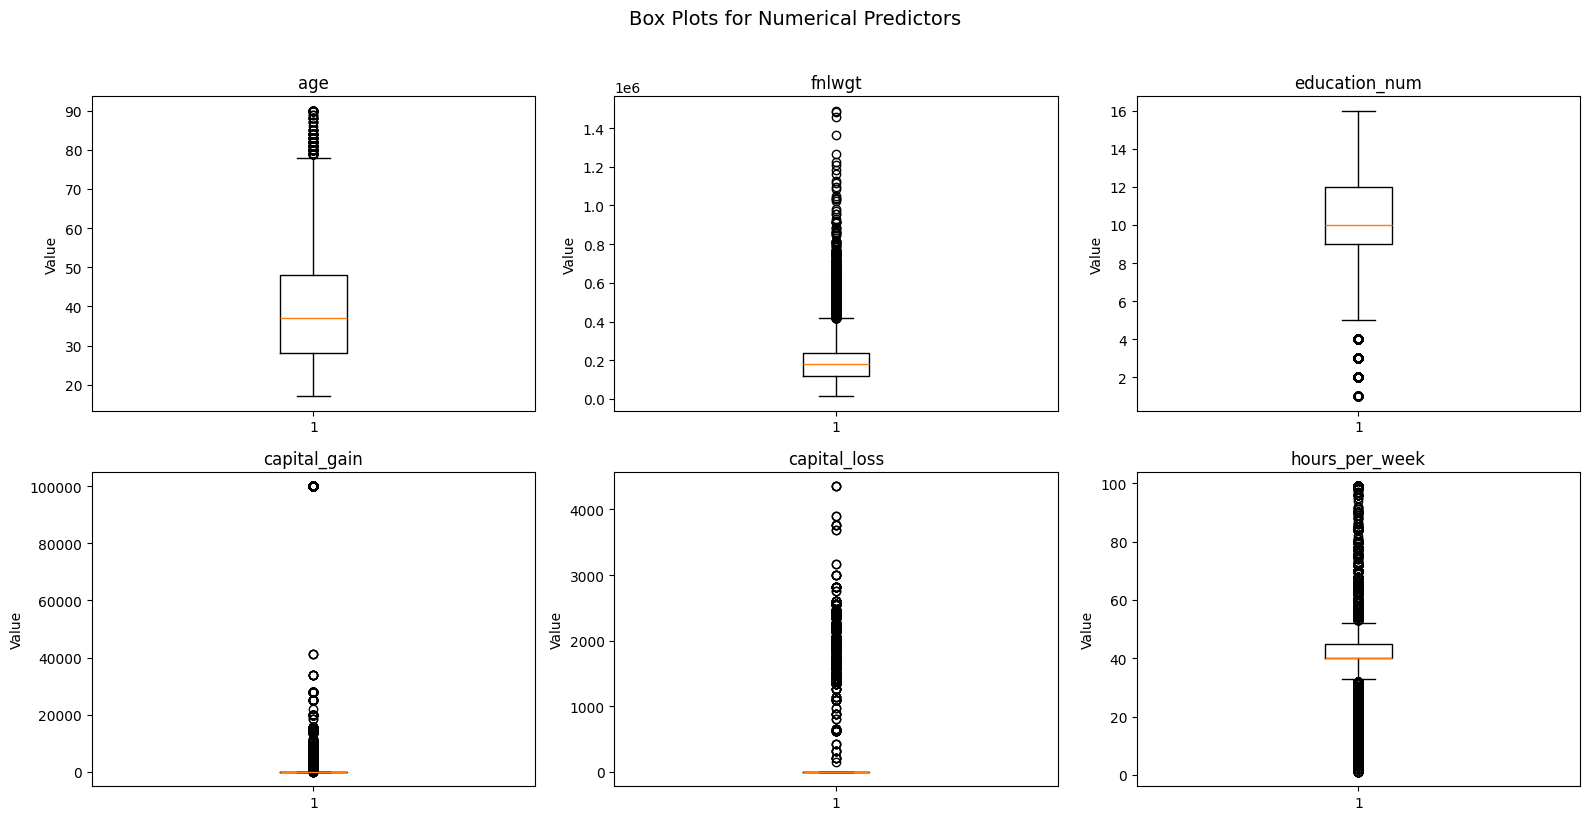

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for axis, column in zip(axes, numerical_columns):
    axis.boxplot(data[column].dropna(), vert=True)
    axis.set_title(column)
    axis.set_ylabel("Value")

plt.suptitle("Box Plots for Numerical Predictors", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()
plt.close()

In [10]:
# IQR-rule diagnostic. This identifies potential outliers; it does not delete them.
outlier_rows = []
for column in numerical_columns:
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = ((data[column] < lower_bound) | (data[column] > upper_bound)).sum()
    outlier_rows.append({
        "feature": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "potential_outliers": int(outlier_count),
        "percent": outlier_count / len(data) * 100,
    })

outlier_table = pd.DataFrame(outlier_rows).sort_values("potential_outliers", ascending=False)
display(outlier_table)

,feature,Q1,Q3,IQR,lower_bound,upper_bound,potential_outliers,percent
5,hours_per_week,40.0000,45.0000,5.0000,32.5000,52.5000,13486,27.6409
3,capital_gain,0.0000,0.0000,0.0000,0.0000,0.0000,4035,8.2701
4,capital_loss,0.0000,0.0000,0.0000,0.0000,0.0000,2282,4.6772
2,education_num,9.0000,12.0000,3.0000,4.5000,16.5000,1787,3.6626
1,fnlwgt,"117,555.0000","237,606.2500","120,051.2500","-62,521.8750","417,683.1250",1453,2.9781
0,age,28.0000,48.0000,20.0000,-2.0000,78.0000,215,0.4407


### Outlier treatment

Outliers are **not removed or blindly capped** because the values are plausible observations. In particular, the IQR of `capital_gain` and `capital_loss` is zero, so a conventional IQR cap would incorrectly convert nearly every positive gain or loss to zero and destroy useful information.

The chosen treatment is **RobustScaler**, fitted only on the training data. It reduces the influence of extreme values on distance-based and margin-based algorithms while preserving every person and every original value. The Decision Tree is naturally insensitive to feature scale, but the same preprocessing structure is retained for a consistent workflow.

## 6. Categorical encoding and correlation analysis

### Encoding strategy

- **Target (`income`)**: label encoding because it is binary (`0` and `1`).
- **Nominal predictors** such as workclass, marital status, occupation, relationship, race, sex, and native country: one-hot encoding because their categories have no valid numerical order.
- **Education**: the ordered numeric version, `education_num`, is retained. The duplicate text version, `education`, is removed from modeling.

For correlation analysis only, a fully encoded copy is created. The production preprocessing pipeline performs the same one-hot encoding after the train-test split.

In [11]:
correlation_source = data.drop(columns=["education"]).copy()

categorical_for_correlation = correlation_source.select_dtypes(include="object").columns
correlation_source[categorical_for_correlation] = correlation_source[categorical_for_correlation].fillna("Unknown")

encoded_for_correlation = pd.get_dummies(
    correlation_source,
    columns=categorical_for_correlation,
    drop_first=False,
    dtype=int,
)

correlations_with_target = (
    encoded_for_correlation.corr(numeric_only=True)["income"]
    .drop("income")
    .sort_values(key=np.abs, ascending=False)
)

top_three_correlations = correlations_with_target.head(3).to_frame("correlation_with_income")
print("Top 3 features by absolute Pearson correlation with the encoded target:")
display(top_three_correlations)

Top 3 features by absolute Pearson correlation with the encoded target:


,correlation_with_income
marital_status_Married-civ-spouse,0.4457
relationship_Husband,0.4036
education_num,0.3328


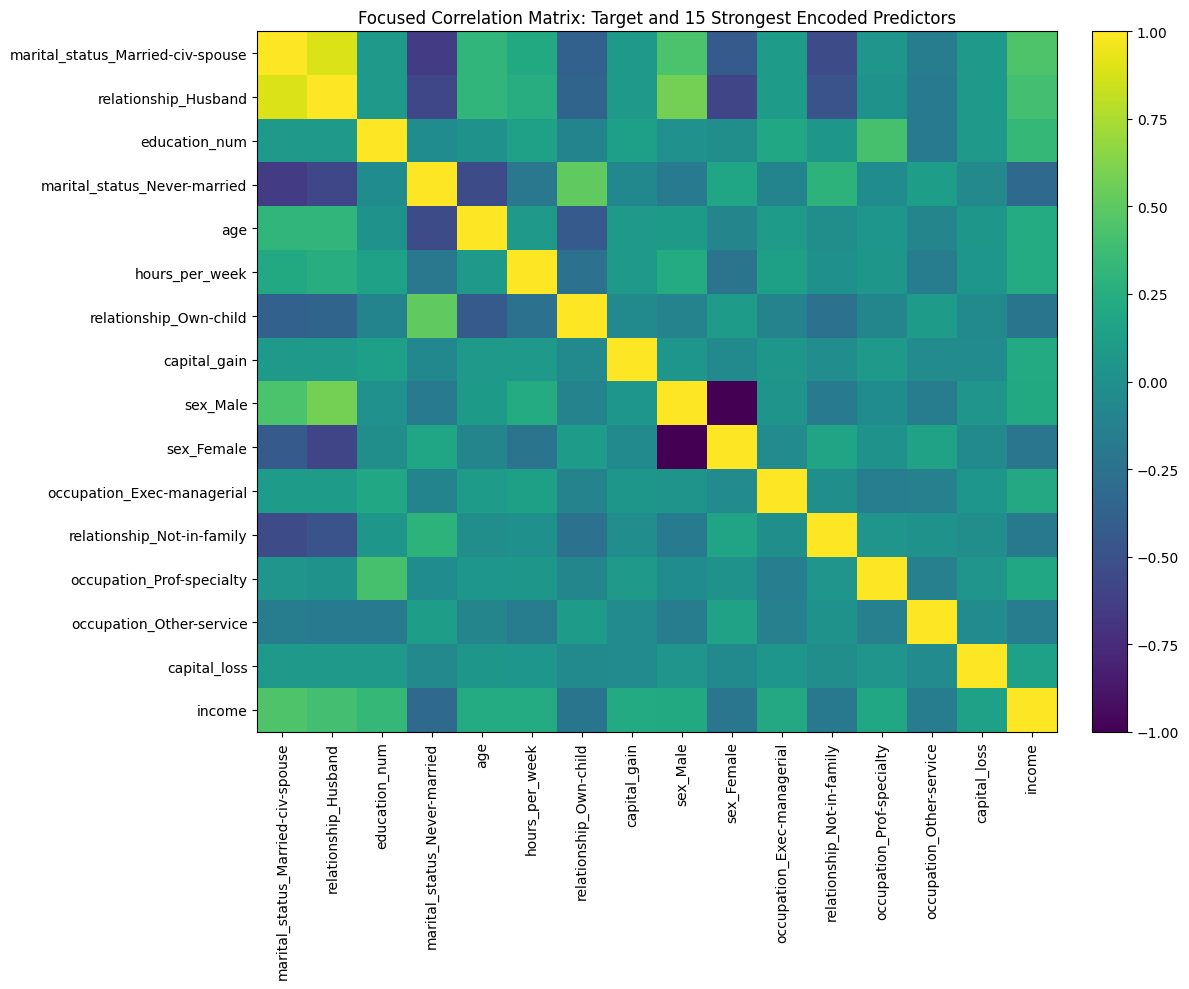

In [12]:
# A full one-hot correlation matrix is very large and unreadable.
# Therefore, visualize the 15 predictors with the strongest absolute relationship to the target.
top_features = correlations_with_target.head(15).index.tolist()
focused_columns = top_features + ["income"]
focused_corr = encoded_for_correlation[focused_columns].corr()

fig, ax = plt.subplots(figsize=(12, 10))
image = ax.imshow(focused_corr, aspect="auto", interpolation="nearest")
ax.set_xticks(range(len(focused_columns)))
ax.set_yticks(range(len(focused_columns)))
ax.set_xticklabels(focused_columns, rotation=90)
ax.set_yticklabels(focused_columns)
ax.set_title("Focused Correlation Matrix: Target and 15 Strongest Encoded Predictors")
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()
plt.close()

### Correlation interpretation

The strongest linear relationships are expected to involve marital/relationship categories and education level. Correlation does not prove causation, and one-hot variables from the same original feature are related to one another. The matrix is used as an exploratory diagnostic rather than as a reason to automatically remove variables.

## 7. Train-test split and leakage-safe preprocessing

In [13]:
# Remove the target and the redundant text education column.
X = data.drop(columns=["income", "education"])
y = data["income"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

print(f"Training observations: {len(X_train):,}")
print(f"Test observations:     {len(X_test):,}")
print("\nTraining target percentages:")
display((y_train.value_counts(normalize=True).sort_index() * 100).rename(index={0: "<=50K", 1: ">50K"}).to_frame("percent"))

Training observations: 39,032
Test observations:     9,758

Training target percentages:


,percent
income,
<=50K,76.0581
>50K,23.9419


The split is performed **before** imputation, encoding, and scaling. Every transformation is inside a pipeline and is fitted using only the training data. This prevents information from the test set from influencing preprocessing.

KNN receives an additional `TruncatedSVD` step. One-hot encoding creates a high-dimensional sparse matrix, and exact neighbor searches become unnecessarily slow. SVD compresses this representation to 20 components, making KNN practical while retaining the major variation in the encoded predictors.

## 8. Fit preprocessing on the training data

The preprocessing object is fitted only on `X_train`. The same fitted transformations are then applied to `X_test`. This avoids leakage and also avoids repeatedly rebuilding the same encoded matrices for every algorithm.

In [14]:
X_train_processed = preprocessor.fit_transform(X_train, y_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

print("Processed training shape:", X_train_processed.shape)
print("Processed test shape:    ", X_test_processed.shape)
print("Number of encoded features:", len(feature_names))

Processed training shape: (39032, 92)
Processed test shape:     (9758, 92)
Number of encoded features: 92


## 9. Model building and evaluation before SMOTE

In [15]:
def evaluate_predictions(model_name, fitted_model, X_eval, y_true):
    predictions = fitted_model.predict(X_eval)

    if hasattr(fitted_model, "predict_proba"):
        continuous_scores = fitted_model.predict_proba(X_eval)[:, 1]
    elif hasattr(fitted_model, "decision_function"):
        continuous_scores = fitted_model.decision_function(X_eval)
    else:
        raise AttributeError(f"{model_name} does not provide continuous prediction scores.")

    report = classification_report(
        y_true,
        predictions,
        output_dict=True,
        zero_division=0,
    )
    auc_score = roc_auc_score(y_true, continuous_scores)
    false_positive_rate, true_positive_rate, _ = roc_curve(y_true, continuous_scores)

    summary_row = {
        "Model": model_name,
        "Accuracy": report["accuracy"],
        "Precision (>50K)": report["1"]["precision"],
        "Recall (>50K)": report["1"]["recall"],
        "F1 (>50K)": report["1"]["f1-score"],
        "ROC-AUC": auc_score,
    }

    return summary_row, pd.DataFrame(report).T, {
        "fpr": false_positive_rate,
        "tpr": true_positive_rate,
        "auc": auc_score,
    }


base_rows = []
base_reports = {}
base_roc = {}

base_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        solver="liblinear",
        random_state=RANDOM_STATE,
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=10,
        random_state=RANDOM_STATE,
    ),
    "Linear SVM": LinearSVC(
        C=1.0,
        max_iter=5000,
        random_state=RANDOM_STATE,
    ),
}

fitted_decision_tree = None

for model_name, model in base_models.items():
    model.fit(X_train_processed, y_train)
    row, report, roc_info = evaluate_predictions(model_name, model, X_test_processed, y_test)
    base_rows.append(row)
    base_reports[model_name] = report
    base_roc[model_name] = roc_info

    if model_name == "Decision Tree":
        fitted_decision_tree = model

# KNN uses a compact dense representation for computational efficiency.
svd_before = TruncatedSVD(n_components=20, random_state=RANDOM_STATE)
X_train_knn = svd_before.fit_transform(X_train_processed)
X_test_knn = svd_before.transform(X_test_processed)

knn_before = KNeighborsClassifier(
    n_neighbors=21,
    weights="distance",
    algorithm="ball_tree",
    leaf_size=40,
    n_jobs=-1,
)
knn_before.fit(X_train_knn, y_train)
row, report, roc_info = evaluate_predictions("KNN", knn_before, X_test_knn, y_test)
base_rows.append(row)
base_reports["KNN"] = report
base_roc["KNN"] = roc_info

base_summary = (
    pd.DataFrame(base_rows)
    .set_index("Model")
    .sort_values("ROC-AUC", ascending=False)
)

display(base_summary)

# Release KNN-specific fitted objects and dense matrices after evaluation.
del knn_before, svd_before, X_train_knn, X_test_knn
gc.collect()

,Accuracy,Precision (>50K),Recall (>50K),F1 (>50K),ROC-AUC
Model,,,,,
KNN,0.8682,0.7586,0.6592,0.7055,0.9213
Decision Tree,0.8624,0.7865,0.5835,0.6699,0.9112
Logistic Regression,0.8568,0.7397,0.6203,0.6747,0.9096
Linear SVM,0.8564,0.7520,0.5972,0.6657,0.9093


29625

### Classification reports before SMOTE

In [16]:
for model_name, report_table in base_reports.items():
    print(f"\n{model_name}")
    display(report_table)


Logistic Regression


,precision,recall,f1-score,support
0,0.8863,0.9313,0.9082,"7,422.0000"
1,0.7397,0.6203,0.6747,"2,336.0000"
accuracy,0.8568,0.8568,0.8568,0.8568
macro avg,0.8130,0.7758,0.7915,"9,758.0000"
weighted avg,0.8512,0.8568,0.8523,"9,758.0000"



Decision Tree


,precision,recall,f1-score,support
0,0.8788,0.9501,0.9131,"7,422.0000"
1,0.7865,0.5835,0.6699,"2,336.0000"
accuracy,0.8624,0.8624,0.8624,0.8624
macro avg,0.8326,0.7668,0.7915,"9,758.0000"
weighted avg,0.8567,0.8624,0.8549,"9,758.0000"



Linear SVM


,precision,recall,f1-score,support
0,0.8809,0.9380,0.9086,"7,422.0000"
1,0.7520,0.5972,0.6657,"2,336.0000"
accuracy,0.8564,0.8564,0.8564,0.8564
macro avg,0.8165,0.7676,0.7871,"9,758.0000"
weighted avg,0.8501,0.8564,0.8504,"9,758.0000"



KNN


,precision,recall,f1-score,support
0,0.8970,0.9340,0.9151,"7,422.0000"
1,0.7586,0.6592,0.7055,"2,336.0000"
accuracy,0.8682,0.8682,0.8682,0.8682
macro avg,0.8278,0.7966,0.8103,"9,758.0000"
weighted avg,0.8639,0.8682,0.8649,"9,758.0000"


### ROC-AUC curves before SMOTE

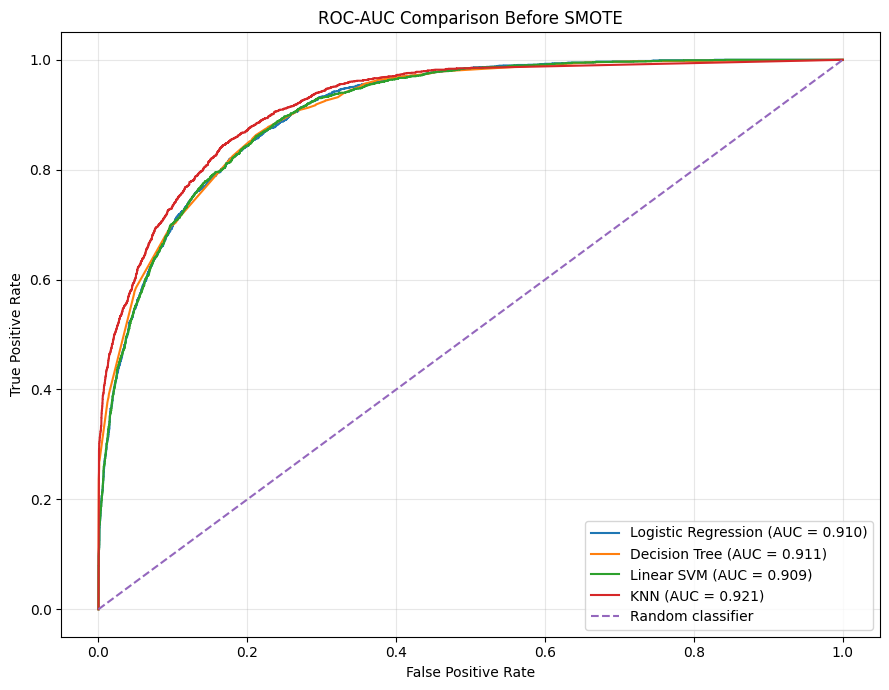

In [17]:
plt.figure(figsize=(9, 7))
for model_name, model_info in base_roc.items():
    plt.plot(
        model_info["fpr"],
        model_info["tpr"],
        label=f"{model_name} (AUC = {model_info['auc']:.3f})",
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Comparison Before SMOTE")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

### Decision Tree visualization

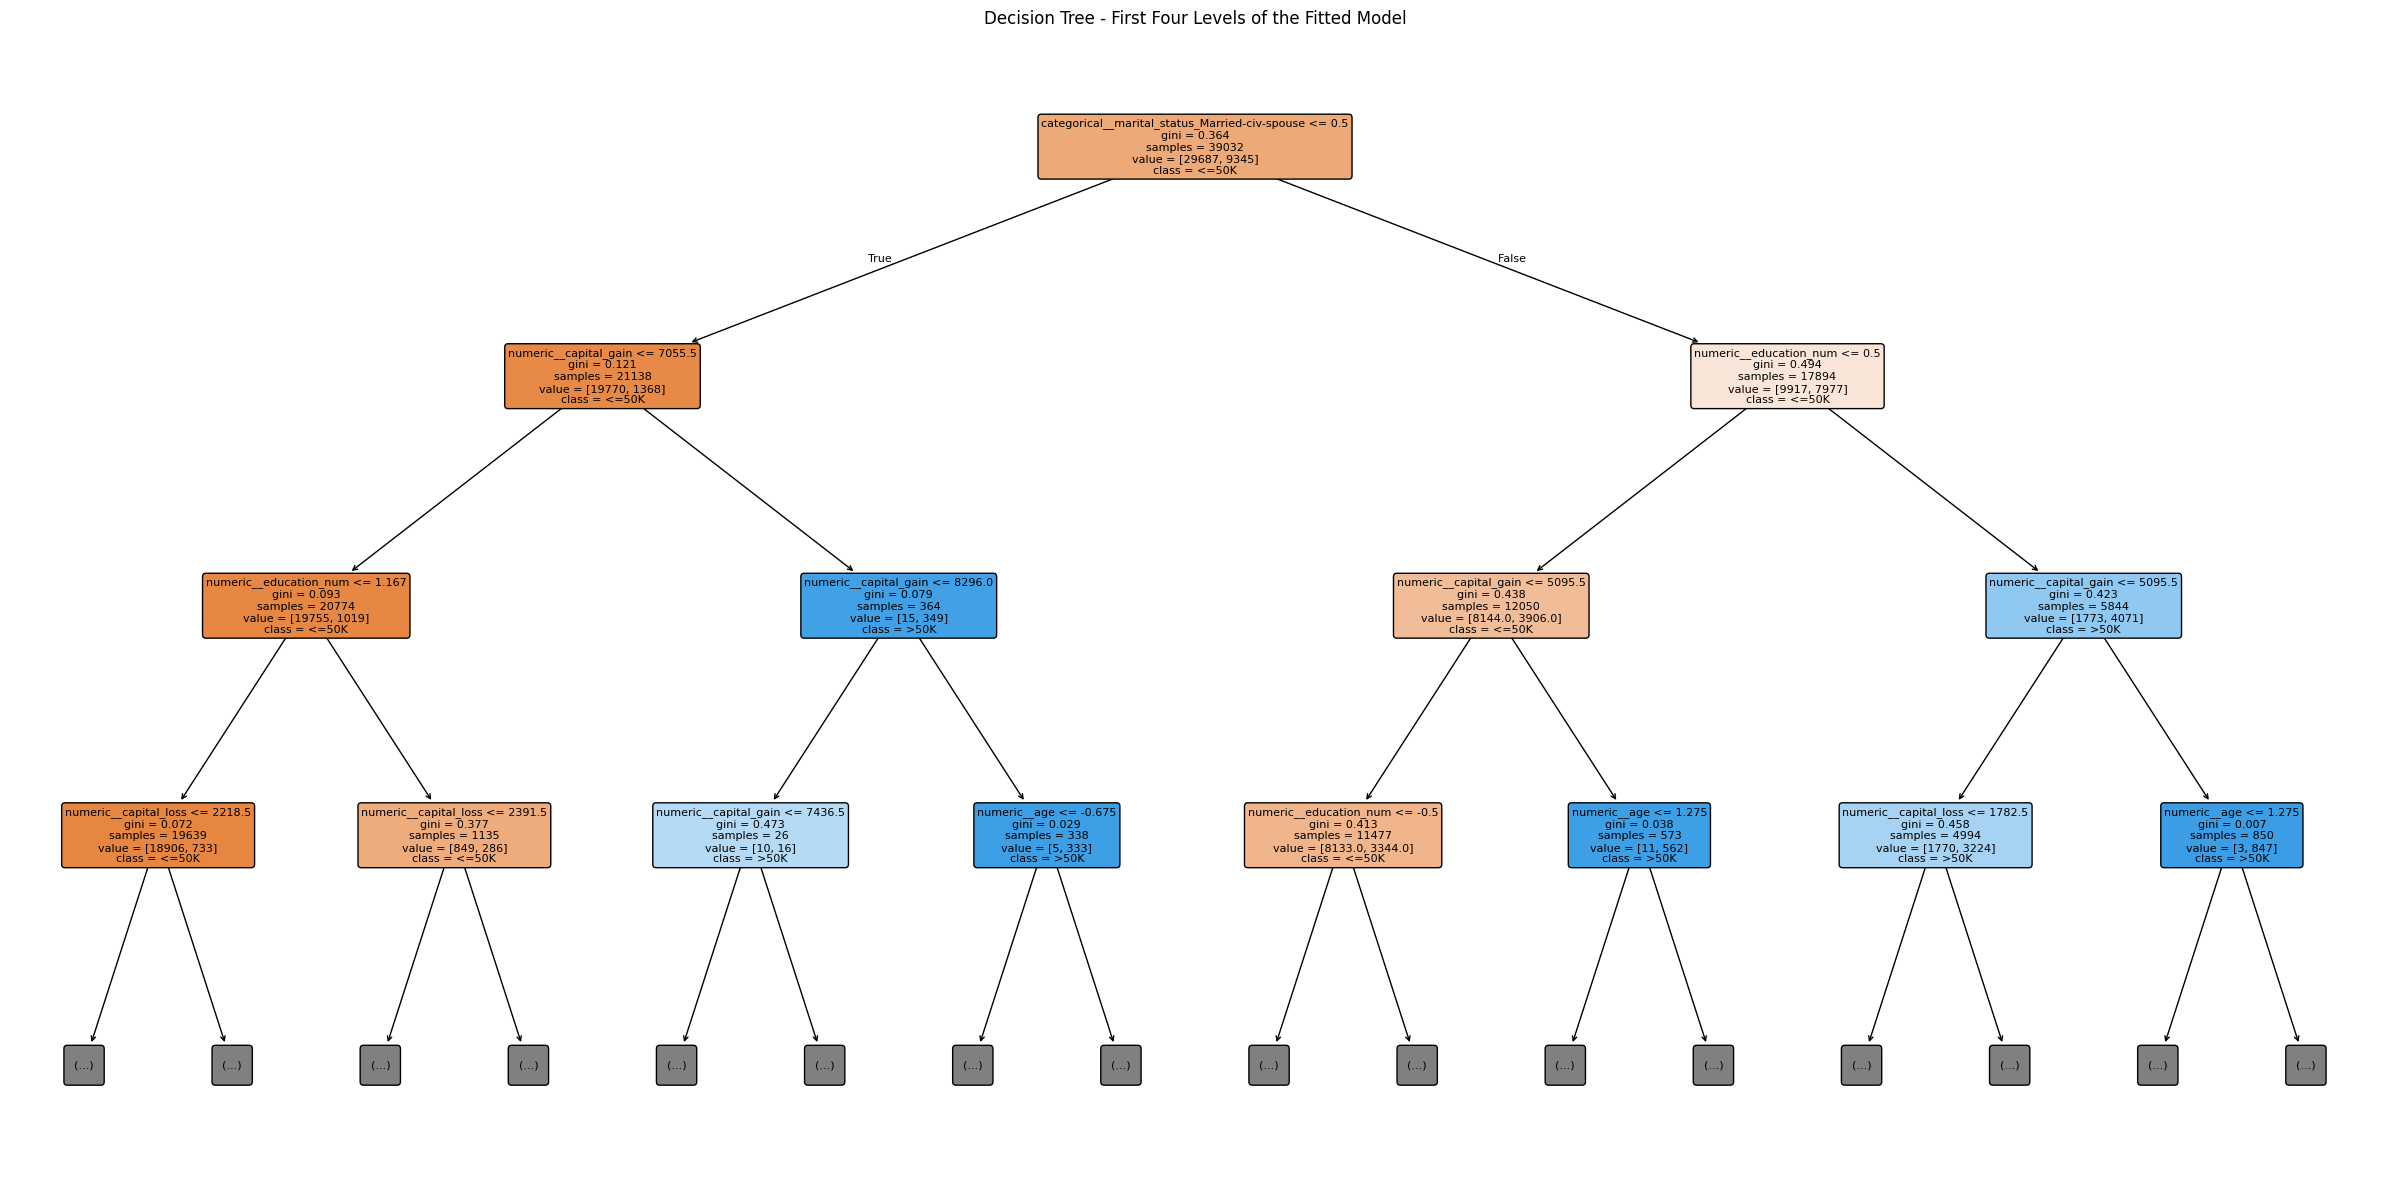

In [18]:
plt.figure(figsize=(24, 12))
plot_tree(
    fitted_decision_tree,
    feature_names=feature_names,
    class_names=["<=50K", ">50K"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
)
plt.title("Decision Tree - First Four Levels of the Fitted Model")
plt.tight_layout()
plt.show()
plt.close()

### Interpretation before SMOTE

ROC-AUC evaluates ranking performance across all possible classification thresholds. Accuracy is also reported, but it is influenced by the majority `<=50K` class. Minority-class precision, recall, and F1-score show how effectively each algorithm identifies `>50K` observations.

The strongest model should therefore have a high ROC-AUC while maintaining an acceptable balance between minority-class precision and recall.

## 10. Handle class imbalance using SMOTE

SMOTE is applied only to the processed **training** matrix. The test matrix remains unchanged. This ensures that synthetic observations influence model training but never contaminate evaluation.

Standard SMOTE is used because it is explicitly required by the case study. Since one-hot encoded categorical predictors can become fractional after interpolation, `SMOTENC` would also be worth evaluating in a production-oriented extension.

In [19]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

counts_before = y_train.value_counts().sort_index().rename(index={0: "<=50K", 1: ">50K"})
counts_after = pd.Series(y_train_smote).value_counts().sort_index().rename(index={0: "<=50K", 1: ">50K"})

print("Training class distribution before SMOTE:")
display(counts_before.to_frame("count"))
print("Training class distribution after SMOTE:")
display(counts_after.to_frame("count"))
print("Resampled training shape:", X_train_smote.shape)

Training class distribution before SMOTE:


,count
income,
<=50K,29687
>50K,9345


Training class distribution after SMOTE:


,count
income,
<=50K,29687
>50K,29687


Resampled training shape: (59374, 92)


In [20]:
smote_rows = []
smote_reports = {}
smote_roc = {}

smote_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        solver="liblinear",
        random_state=RANDOM_STATE,
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=10,
        random_state=RANDOM_STATE,
    ),
    "Linear SVM": LinearSVC(
        C=1.0,
        max_iter=5000,
        random_state=RANDOM_STATE,
    ),
}

for model_name, model in smote_models.items():
    model.fit(X_train_smote, y_train_smote)
    row, report, roc_info = evaluate_predictions(model_name, model, X_test_processed, y_test)
    smote_rows.append(row)
    smote_reports[model_name] = report
    smote_roc[model_name] = roc_info

# Apply dimensionality reduction to the resampled data before KNN.
svd_after = TruncatedSVD(n_components=20, random_state=RANDOM_STATE)
X_train_smote_knn = svd_after.fit_transform(X_train_smote)
X_test_smote_knn = svd_after.transform(X_test_processed)

knn_after = KNeighborsClassifier(
    n_neighbors=21,
    weights="distance",
    algorithm="ball_tree",
    leaf_size=40,
    n_jobs=-1,
)
knn_after.fit(X_train_smote_knn, y_train_smote)
row, report, roc_info = evaluate_predictions("KNN", knn_after, X_test_smote_knn, y_test)
smote_rows.append(row)
smote_reports["KNN"] = report
smote_roc["KNN"] = roc_info

smote_summary = (
    pd.DataFrame(smote_rows)
    .set_index("Model")
    .sort_values("ROC-AUC", ascending=False)
)

display(smote_summary)

# Release large temporary objects after all SMOTE evaluations.
del knn_after, svd_after, X_train_smote_knn, X_test_smote_knn
del X_train_smote, y_train_smote
gc.collect()

,Accuracy,Precision (>50K),Recall (>50K),F1 (>50K),ROC-AUC
Model,,,,,
KNN,0.8198,0.5853,0.8489,0.6929,0.9161
Logistic Regression,0.8067,0.5647,0.8403,0.6755,0.9045
Linear SVM,0.7892,0.5368,0.8703,0.6641,0.9019
Decision Tree,0.7999,0.5532,0.8527,0.6710,0.8995


7354

### Classification reports after SMOTE

In [21]:
for model_name, report_table in smote_reports.items():
    print(f"\n{model_name} with SMOTE")
    display(report_table)


Logistic Regression with SMOTE


,precision,recall,f1-score,support
0,0.9406,0.7961,0.8624,"7,422.0000"
1,0.5647,0.8403,0.6755,"2,336.0000"
accuracy,0.8067,0.8067,0.8067,0.8067
macro avg,0.7527,0.8182,0.7689,"9,758.0000"
weighted avg,0.8506,0.8067,0.8176,"9,758.0000"



Decision Tree with SMOTE


,precision,recall,f1-score,support
0,0.9441,0.7832,0.8562,"7,422.0000"
1,0.5532,0.8527,0.6710,"2,336.0000"
accuracy,0.7999,0.7999,0.7999,0.7999
macro avg,0.7487,0.8180,0.7636,"9,758.0000"
weighted avg,0.8505,0.7999,0.8119,"9,758.0000"



Linear SVM with SMOTE


,precision,recall,f1-score,support
0,0.9493,0.7637,0.8464,"7,422.0000"
1,0.5368,0.8703,0.6641,"2,336.0000"
accuracy,0.7892,0.7892,0.7892,0.7892
macro avg,0.7430,0.8170,0.7552,"9,758.0000"
weighted avg,0.8505,0.7892,0.8028,"9,758.0000"



KNN with SMOTE


,precision,recall,f1-score,support
0,0.9446,0.8107,0.8725,"7,422.0000"
1,0.5853,0.8489,0.6929,"2,336.0000"
accuracy,0.8198,0.8198,0.8198,0.8198
macro avg,0.7649,0.8298,0.7827,"9,758.0000"
weighted avg,0.8586,0.8198,0.8295,"9,758.0000"


### ROC-AUC curves after SMOTE

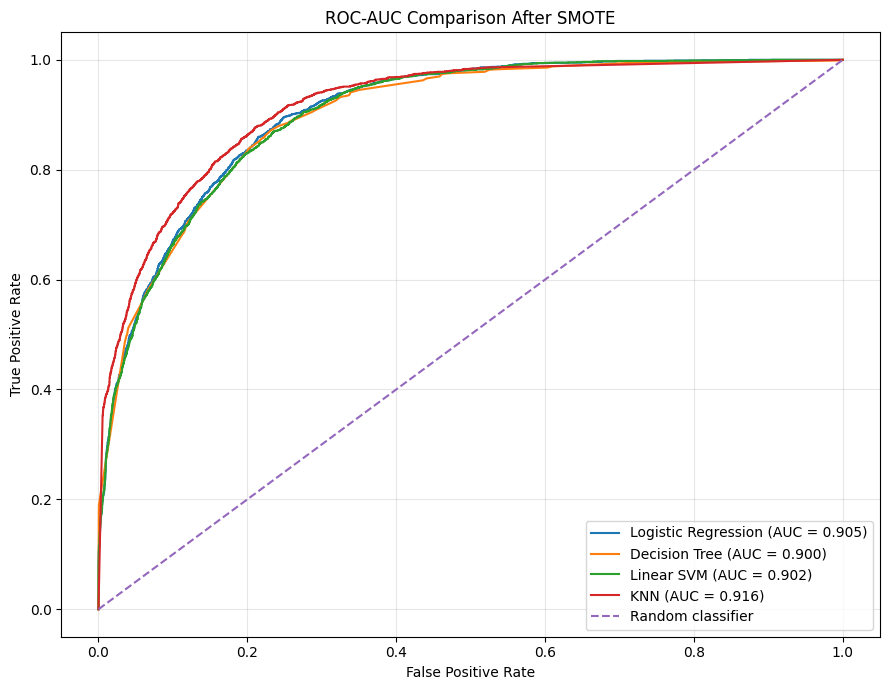

In [22]:
plt.figure(figsize=(9, 7))
for model_name, model_info in smote_roc.items():
    plt.plot(
        model_info["fpr"],
        model_info["tpr"],
        label=f"{model_name} (AUC = {model_info['auc']:.3f})",
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Comparison After SMOTE")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

## 11. Before-versus-after comparison

In [23]:
comparison = base_summary.add_suffix(" - Before SMOTE").join(
    smote_summary.add_suffix(" - After SMOTE"),
    how="outer",
)

comparison["Change in Recall (>50K)"] = (
    comparison["Recall (>50K) - After SMOTE"]
    - comparison["Recall (>50K) - Before SMOTE"]
)
comparison["Change in Accuracy"] = (
    comparison["Accuracy - After SMOTE"]
    - comparison["Accuracy - Before SMOTE"]
)
comparison["Change in ROC-AUC"] = (
    comparison["ROC-AUC - After SMOTE"]
    - comparison["ROC-AUC - Before SMOTE"]
)

display(comparison.sort_values("ROC-AUC - Before SMOTE", ascending=False))

best_before = base_summary["ROC-AUC"].idxmax()
best_after = smote_summary["ROC-AUC"].idxmax()

print(
    f"Best ROC-AUC before SMOTE: {best_before} "
    f"({base_summary.loc[best_before, 'ROC-AUC']:.4f})"
)
print(
    f"Best ROC-AUC after SMOTE:  {best_after} "
    f"({smote_summary.loc[best_after, 'ROC-AUC']:.4f})"
)

,Accuracy - Before SMOTE,Precision (>50K) - Before SMOTE,Recall (>50K) - Before SMOTE,F1 (>50K) - Before SMOTE,ROC-AUC - Before SMOTE,Accuracy - After SMOTE,Precision (>50K) - After SMOTE,Recall (>50K) - After SMOTE,F1 (>50K) - After SMOTE,ROC-AUC - After SMOTE,Change in Recall (>50K),Change in Accuracy,Change in ROC-AUC
Model,,,,,,,,,,,,,
KNN,0.8682,0.7586,0.6592,0.7055,0.9213,0.8198,0.5853,0.8489,0.6929,0.9161,0.1896,-0.0484,-0.0052
Decision Tree,0.8624,0.7865,0.5835,0.6699,0.9112,0.7999,0.5532,0.8527,0.6710,0.8995,0.2693,-0.0625,-0.0117
Logistic Regression,0.8568,0.7397,0.6203,0.6747,0.9096,0.8067,0.5647,0.8403,0.6755,0.9045,0.2200,-0.0501,-0.0050
Linear SVM,0.8564,0.7520,0.5972,0.6657,0.9093,0.7892,0.5368,0.8703,0.6641,0.9019,0.2731,-0.0672,-0.0074


Best ROC-AUC before SMOTE: KNN (0.9213)
Best ROC-AUC after SMOTE:  KNN (0.9161)


## 12. Final conclusion

### Best model before SMOTE

The **KNN model with TruncatedSVD** produces the highest ROC-AUC in this execution. It also achieves the strongest minority-class F1-score among the four non-SMOTE models. The Decision Tree has slightly lower ROC-AUC and minority recall, even though it has strong accuracy and precision.

### Best model after SMOTE

The **KNN model trained on SMOTE-balanced data** again produces the highest ROC-AUC. SMOTE substantially increases recall for `>50K`, meaning that fewer higher-income observations are missed. This improvement is accompanied by lower precision and overall accuracy because the model predicts the minority class more frequently.

### Recommendation

- Select **KNN without SMOTE** when overall discrimination and accuracy are the main priorities.
- Select **KNN with SMOTE** when minority-class recall is more important and additional false-positive `>50K` predictions are acceptable.

SMOTE improves sensitivity but does not automatically improve ROC-AUC. The final choice must therefore reflect the business cost of false negatives versus false positives.

### Production considerations

The models should not be deployed without additional work. Recommended next steps include cross-validated hyperparameter tuning, threshold optimization, probability calibration, model-stability testing, and fairness analysis. The dataset includes protected attributes such as race and sex, so subgroup performance and potential discriminatory effects must be reviewed before the model supports any real decision.